This experiment helps debug/explain bad build-time weak scaling for dragonfly topology

# 0. User Parameters, Imports, Environment

## User Parameters

In [1]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_build_debug'

# Configuration parameters
node_counts = [1,2,4,8,16,32,64,128]
groups_per_node = [1,2,4,8,16] # Total groups will scale with the number of nodes
routers_per_group = 8 
hosts_per_router = 8

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 1

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

workflow_dir: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


## Calculated 'Constants'

In [2]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

'/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif'

## Imports

In [3]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [4]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [5]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif already exists.


## Prepare the e4s-cl profile

In [6]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.py


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.py already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.so


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.so already in profile's files


> e4s-cl profile edit --image /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif


## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [7]:
check_mpi_binding(sst_container_dest_path)

e4s-cl profile : sst-experiments
profile image  : /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif
container SST  : /opt/SST/16.0.0/libexec/sstsim.x
container MPI  : libmpi.so.12
bound host MPI : libmpi_cray.so.12 -> /opt/cray/pe/lib64/libmpi_cray.so.12
bound host PMI : libpals.so.0, libpmi.so.0, libpmi2.so.0
OK: e4s-cl will inject a host MPI into the container.


True

# 2. Build Benchmarks

In [8]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make -j10']


/opt/SST/16.0.0/bin//sst-register merlin_benchmark merlin_benchmark_LIBDIR=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark


# 3. Generate Argument Tuples

In [9]:
run_specs = []
for node_count in node_counts:
    for gpn in groups_per_node:
        num_groups = gpn * node_count
        run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = (node_count,),
        topologies=('dragonfly',),
        global_params={'stop_at': (200),
                       'verbose': 5},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,)
        },
        experiment_name=experiment_name)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

Generated 40 run specifications.
Example spec:  MerlinRunSpec(run_id='e1423fe343', run_name='dragonfly_build_debug_dragonfly_n1_r1_e1423fe343', launcher={'srun': ['--nodes=1', '--ntasks-per-node=1'], 'mpirun': ['-n', '1', '-N', '1']}, sst_args=['--timing-info=3', '--parallel-load=SINGLE'], config_args=['--dragonfly-adaptive-threshold', '2.0', '--dragonfly-algorithm', 'minimal', '--dragonfly-global-routing-mode', 'absolute', '--dragonfly-hosts-per-router', '8', '--dragonfly-intergroup-links', '1', '--dragonfly-num-groups', '1', '--dragonfly-routers-per-group', '8', '--flit-size-bytes', '8', '--link-bw-gbps', '4', '--link-lat-ns', '1', '--stop-at', '200ns', '--tg-input-buf-size', '4kB', '--tg-input-latency', '20ns', '--tg-output-buf-size', '4kB', '--tg-output-latency', '20ns', '--topology', 'dragonfly', '--verbose', '5', '--xbar-bw-gbps', '4'], metadata={'experiment_name': 'dragonfly_build_debug', 'run_name': 'dragonfly_build_debug_dragonfly_n1_r1_e1423fe343', 'run_id': 'e1423fe343', 'to

# 4. Launch Runs

In [10]:

os.makedirs(output_dir, exist_ok=True)

for run_spec in run_specs:
    run_output_dir = os.path.join(output_dir, run_spec.run_name)
    os.makedirs(run_output_dir, exist_ok=True)
    cd(run_output_dir)

    status_file_path = os.path.join(run_output_dir, 'status.txt')

    if os.path.exists(status_file_path):
        with open(status_file_path, 'r') as f:
            status = f.read().strip()
        if not FORCED and status in ['COMPLETED', 'SUBMITTED']:
            print(f'Skipping {run_spec.run_name} as it is already {status}')
            continue

    log_file = os.path.join(run_output_dir, 'run.log')
    error_file = os.path.join(run_output_dir, 'run.err')
    profiling_output_file = os.path.join(run_output_dir, 'profiling.json')

    param_file = os.path.join(run_output_dir, 'params.json')
    with open(param_file, 'w') as f:
        json.dump(run_spec.to_dict(), f, indent=2)


    srun_part = " ".join(run_spec.launcher["srun"])
    sst_part = " ".join(run_spec.sst_args)
    config_part = " ".join(run_spec.config_args)

    launch_cmd = (
        f"e4s-cl launch srun --output={log_file} --error={error_file} "
        f"{srun_part} \\\n\t -- sst --profiling-output={profiling_output_file} --timing-info=3 {sst_input_config} "
        f"{sst_part} \\\n\t -- {config_part}"
    )

    
    sbatch_script_path = os.path.join(run_output_dir, 'run.sbatch')

    with open(sbatch_script_path, 'w') as f:
        f.write(f"#!/bin/bash\n")
        f.write(f"echo 'LAUNCHED' > {status_file_path}\n")
        f.write(f"{launch_cmd}\n")
        f.write(f"if [ $? -eq 0 ]; then\n")
        f.write(f"    echo 'COMPLETED' > {status_file_path}\n")
        f.write(f"else\n")
        f.write(f"    echo 'FAILED' > {status_file_path}\n")
        f.write(f"fi\n")

    os.chmod(sbatch_script_path, 0o755)

    sbatch_log = os.path.join(run_output_dir, 'sbatch.log')
    sbatch_err = os.path.join(run_output_dir, 'sbatch.err')
    sbatch_cmd = f"sbatch --job-name={experiment_name} --output={sbatch_log} --error={sbatch_err} {srun_part} {sbatch_script_path}"
    sbatch_submit_file = os.path.join(run_output_dir, 'sbatch_submit_cmd.txt')
    with open(sbatch_submit_file, 'w') as f:
        f.write(f"{sbatch_cmd}\n")

    with open(status_file_path, 'w') as f:
        f.write('SUBMITTED\n')
    run_cmd(sbatch_cmd)

    cd(workflow_dir)

> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n1_r1_e1423fe343
> sbatch --job-name=dragonfly_build_debug --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n1_r1_e1423fe343/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n1_r1_e1423fe343/sbatch.err --nodes=1 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n1_r1_e1423fe343/run.sbatch
Submitted batch job 1639197
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n1_r1_97c491f97c
> sbatch --job-name=dragonfly_build_debug --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_

Submitted batch job 1639210
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n4_r1_54b4eb9124
> sbatch --job-name=dragonfly_build_debug --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n4_r1_54b4eb9124/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n4_r1_54b4eb9124/sbatch.err --nodes=4 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n4_r1_54b4eb9124/run.sbatch
Submitted batch job 1639211
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n8_r1_7821bfec52
> sbatch --job-name=dragonfly_build_debug --output=/lus/bnchlu1/neth/sst-be

# 5. Wait for Job Completion

In [11]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 40


Waiting for jobs to complete... Queue length: 40
Waiting for jobs to complete... Queue length: 40
Waiting for jobs to complete... Queue length: 40
Waiting for jobs to complete... Queue length: 40
Waiting for jobs to complete... Queue length: 40
Waiting for jobs to complete... Queue length: 27
Waiting for jobs to complete... Queue length: 26


KeyboardInterrupt: 

# 6. Collect Simulation Results

In [51]:
log_files = glob.glob(f'{output_dir}/**/run.log', recursive=True)

log_dfs = []
for log_file in log_files:
    param_file = log_file.replace('run.log', 'params.json')
    status_file = log_file.replace('run.log', 'status.txt')
    if os.path.exists(status_file):
        with open(status_file, 'r') as f:
            status = f.read()
            if status.strip() != 'COMPLETED':
                print(f'Run not completed for log file: {log_file}')
                continue
    else:
        print(f'No status file for log file: {log_file}')
        continue
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
    else:
        print(f'Parameter file not found for log file: {log_file}')
        continue

    with open(log_file, 'r') as f:
        log_contents = f.read()

    log_data = []
    for line in log_contents.splitlines():
        tokens = line.split()
        if tokens[0] == 'CHECK':
            break
        if tokens[0] != 'Rank':
            continue

        rank_num = int(tokens[1].rstrip(':'))
        if not tokens[2].isupper():
            continue
        action = tokens[2]
        target_type = tokens[3]
        target_location = tokens[4]
        log_data.append({
            'rank_num': rank_num,
            'action': action,
            'target_type': target_type,
            'target_location': target_location
        })
    log_df = pd.DataFrame(log_data)
    log_df['node_count'] = params.get('node_count', None)
    log_df['dragonfly_num_groups'] = params.get('dragonfly_num_groups', None)
    log_df['dragonfly_groups_per_node'] = params.get('dragonfly_num_groups', None) // params.get('node_count', None)
    log_df['dragonfly_num_routers'] = params.get('dragonfly_num_groups', None) * params.get('dragonfly_routers_per_group', None)
    log_df['dragonfly_routers_per_group'] = params.get('dragonfly_routers_per_group', None)
    log_dfs.append(log_df)
log_dfs
combined_log_df = pd.concat(log_dfs, ignore_index=True)
combined_log_df
combined_log_df.to_csv(experiment_result_file, index=False)

Run not completed for log file: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n128_r1_ef4a5ab282/run.log
Run not completed for log file: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_build_debug_out/dragonfly_build_debug_dragonfly_n128_r1_f9c800ae37/run.log


# 7. Analyze Results

In [54]:
logs = pd.read_csv(experiment_result_file)
logs.head()



,rank_num,action,target_type,target_location,node_count,dragonfly_num_groups,dragonfly_groups_per_node,dragonfly_num_routers,dragonfly_routers_per_group
0,127,CREATING,ROUTER,LOCAL,128,512,4,4096,8
1,127,CREATING,ENDPOINT,LOCAL,128,512,4,4096,8
2,127,CREATING,LINK,LOCAL,128,512,4,4096,8
3,127,CREATING,ENDPOINT,LOCAL,128,512,4,4096,8
4,127,CREATING,LINK,LOCAL,128,512,4,4096,8


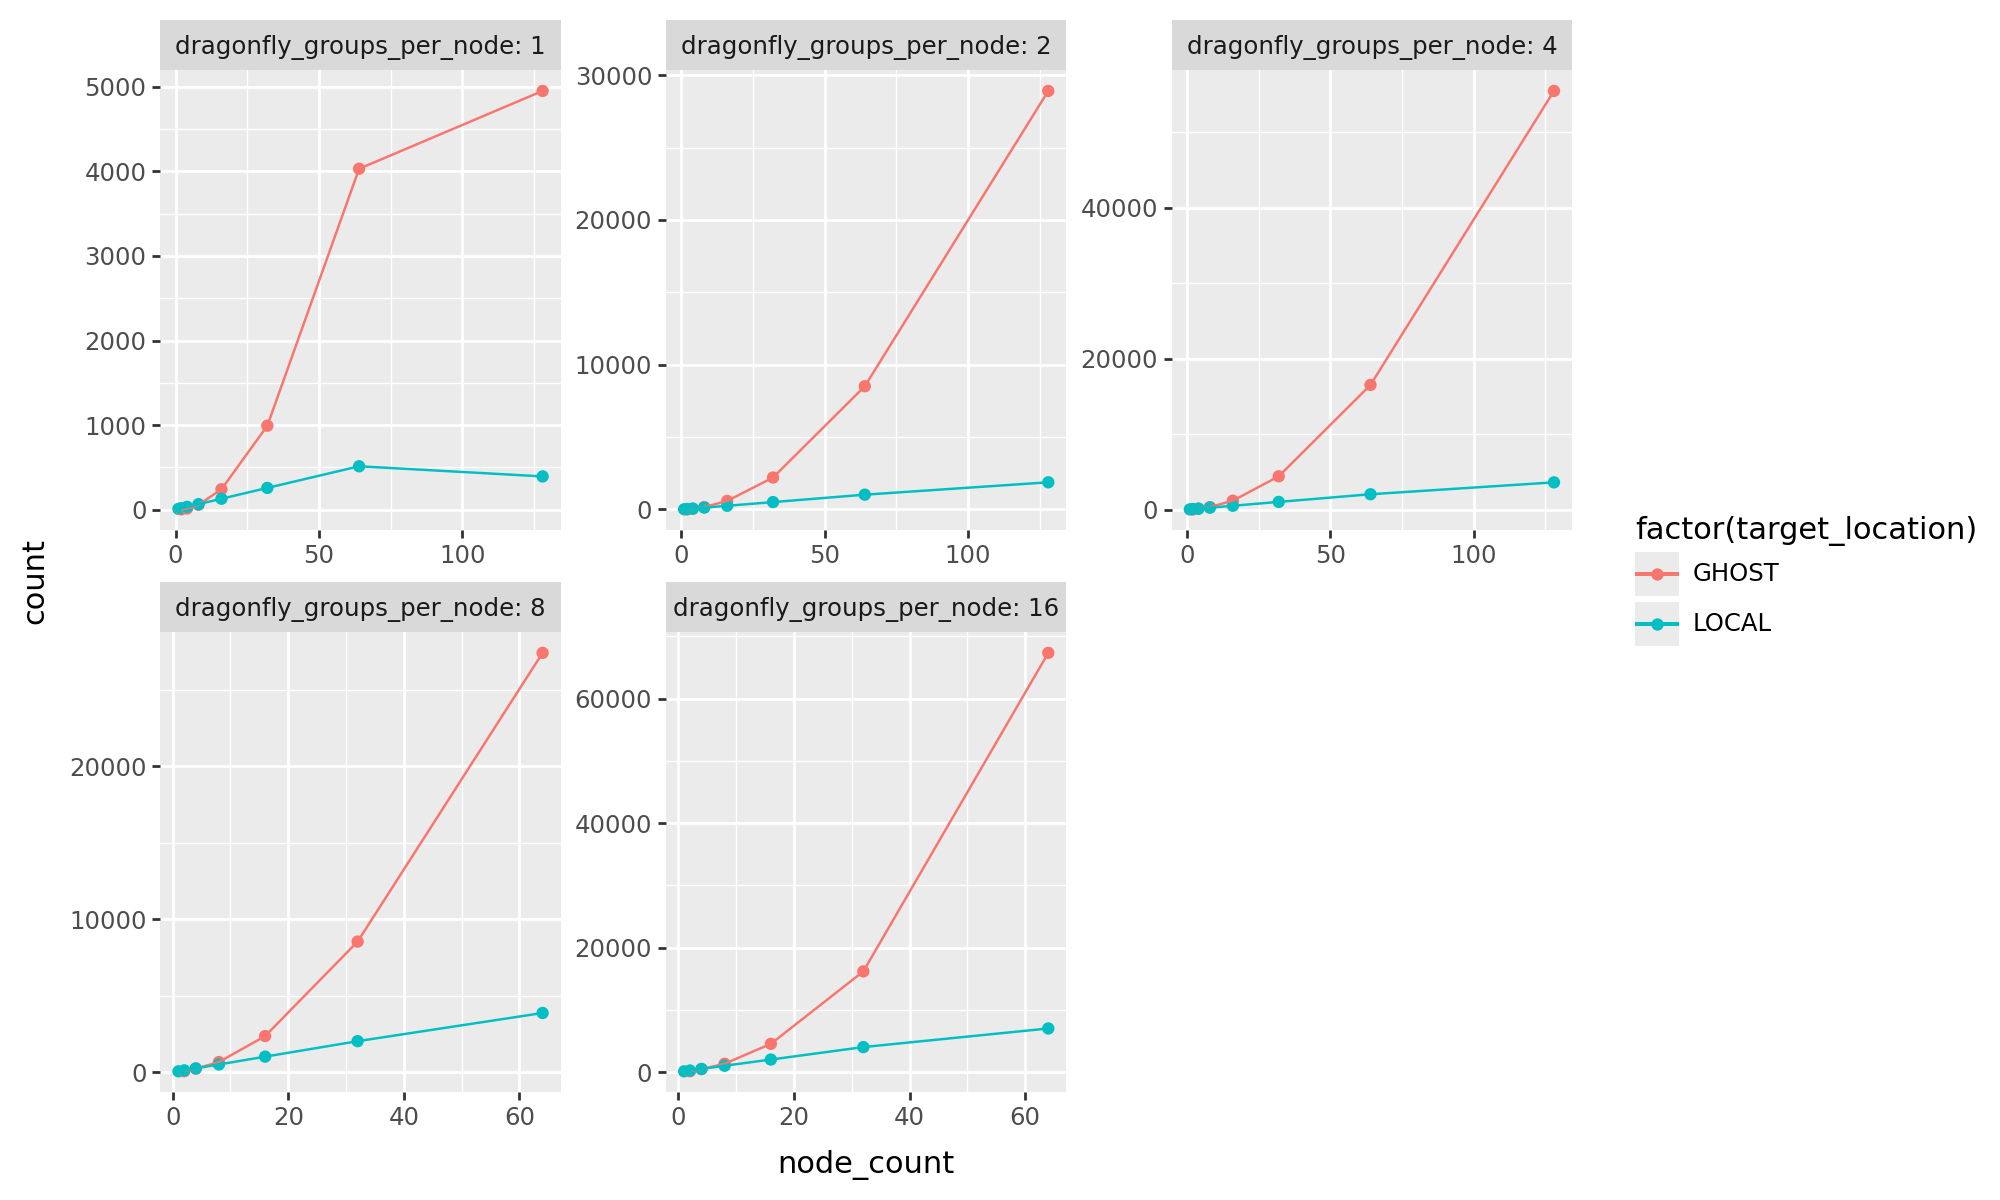

In [55]:
gb = logs.groupby(['node_count', 'dragonfly_groups_per_node', 'dragonfly_num_groups', 'dragonfly_routers_per_group', 'action', 'target_type', 'target_location']).size().reset_index(name='count')

p = ggplot(gb[gb['target_type'] == 'ROUTER'], aes(x='node_count', y='count', color='factor(target_location)'))
p += facet_wrap('~dragonfly_groups_per_node', scales='free', labeller='label_both')
p += geom_point()
p += geom_line()
p += theme(figure_size=(10, 6))
p

Hypothesis: if groups_per_node >= routers_per_group, every node has to make the entire graph

Question: Whys is the local router count not a straight line for groups_per_node != 8?

In [56]:
ghosts = gb[(gb['target_location'] == 'GHOST') & (gb['target_type'] == 'ROUTER') & (gb['action'] == 'CREATING')]
ghosts

,node_count,dragonfly_groups_per_node,dragonfly_num_groups,dragonfly_routers_per_group,action,target_type,target_location,count
24,2,1,2,8,CREATING,ROUTER,GHOST,2
30,2,2,4,8,CREATING,ROUTER,GHOST,8
36,2,4,8,8,CREATING,ROUTER,GHOST,32
42,2,8,16,8,CREATING,ROUTER,GHOST,72
48,2,16,32,8,CREATING,ROUTER,GHOST,144
54,4,1,4,8,CREATING,ROUTER,GHOST,12
60,4,2,8,8,CREATING,ROUTER,GHOST,48
66,4,4,16,8,CREATING,ROUTER,GHOST,120
72,4,8,32,8,CREATING,ROUTER,GHOST,240
78,4,16,64,8,CREATING,ROUTER,GHOST,480


The ghosts created are as follows:
- For each group on this node, create 1 link to each group not on this node.

Thus: groups_per_node * (groups_per_node * (node_count - 1)) remote components per node

multiply by node_count to get the total amount.

This will be reduced by some amount when the same ghost router is used for two different connections to local components.
To do that part statistically, we need to calculate the average number of connections a given router in a group has.

Each group has `groups_per_node * (node_count - 1)` remote links, and `routers_per_group` routers. So each router has
`groups_per_node * (node_count - 1) / routers_per_group` remote links. 

Let's say i have 16 groups, connecting to a remote group with 8 routers. On average, I will have 2 remote links to each router in that group. So I will make 1 ghost router for every 2 remote links. So let's multiply our calculation (routers_per_group / groups_per_node)

In [69]:
ghosts['calced'] = ghosts['node_count'] * ghosts['dragonfly_groups_per_node'] * (ghosts['dragonfly_groups_per_node'] * (ghosts['node_count'] - 1))
ghosts['diff'] = ghosts['calced'] - ghosts['count']
ghosts
#groups_per_node * (node_count - 1) / routers_per_group
ghosts['ghosts_per_router'] = ghosts['dragonfly_groups_per_node'] * (ghosts['node_count'] - 1) / ghosts['dragonfly_routers_per_group']
ghosts[ghosts['ghosts_per_router'] >= 1.0]
ghosts['diff_mod'] = ghosts['calced'] / (ghosts['ghosts_per_router'] ** 2)
ghosts
ghosts['calc2'] = ghosts['calced'] * (ghosts['dragonfly_routers_per_group'] / ghosts['dragonfly_groups_per_node'])
ghosts['diff2'] = ghosts['calc2'] - ghosts['count']
ghosts

,node_count,dragonfly_groups_per_node,dragonfly_num_groups,dragonfly_routers_per_group,action,target_type,target_location,count,calced,diff,ghosts_per_router,diff_mod,calc2,diff2
24,2,1,2,8,CREATING,ROUTER,GHOST,2,2,0,0.125,128.000000,16.0,14.0
30,2,2,4,8,CREATING,ROUTER,GHOST,8,8,0,0.250,128.000000,32.0,24.0
36,2,4,8,8,CREATING,ROUTER,GHOST,32,32,0,0.500,128.000000,64.0,32.0
42,2,8,16,8,CREATING,ROUTER,GHOST,72,128,56,1.000,128.000000,128.0,56.0
48,2,16,32,8,CREATING,ROUTER,GHOST,144,512,368,2.000,128.000000,256.0,112.0
54,4,1,4,8,CREATING,ROUTER,GHOST,12,12,0,0.375,85.333333,96.0,84.0
60,4,2,8,8,CREATING,ROUTER,GHOST,48,48,0,0.750,85.333333,192.0,144.0
66,4,4,16,8,CREATING,ROUTER,GHOST,120,192,72,1.500,85.333333,384.0,264.0
72,4,8,32,8,CREATING,ROUTER,GHOST,240,768,528,3.000,85.333333,768.0,528.0
78,4,16,64,8,CREATING,ROUTER,GHOST,480,3072,2592,6.000,85.333333,1536.0,1056.0
